# 33 · SWE-Agent — sandboxed code-repo agent

> **TL;DR.** Agent with 5 tools (`list_files`, `read_file`, `write_file`, `run_check`, `answer`) constrained to a `working_dir` sandbox. Loop: decide action → execute → observe → repeat until `answer`.

| Property | Value |
|---|---|
| Origin | Yang et al., *SWE-Agent* (Princeton 2024). [arXiv:2405.15793](https://arxiv.org/abs/2405.15793) |
| Sandbox | All FS paths resolved against `working_dir`; escapes rejected |
| Picker | Categorical action — deterministic-picker |
| Default LLM | Llama-3.3-70B |

## 2 · Architecture

```mermaid
flowchart LR
    A([task]) --> D[DECIDE action]
    D --> E[EXECUTE on FS]
    E -->|loop| D
    E -->|answer| Z([final])

    FS[(working_dir<br/>sandbox)]
    E <-.list/read/write/run.-> FS

    style D fill:#fff3e0,stroke:#f57c00
    style E fill:#e3f2fd,stroke:#1976d2
    style FS fill:#f3e5f5,stroke:#7b1fa2
```

## 3 · Theory + safety

The categorical action + sandboxed path are the two safety pillars:
- **`Literal['list_files', ...]`** — no LLM can fabricate a new tool name; structured output enforces the enum.
- **`_safe_path()`** — resolves the relative path and checks it stays under `working_dir.resolve()`. Any `../` escape raises immediately.

## 4 · Setup

In [1]:
import tempfile
from pathlib import Path
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import SWEAgent
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}")

# Create a temp working directory with a buggy file
work = Path(tempfile.mkdtemp(prefix="swe_demo_"))
buggy_file = work / "factorial.py"
buggy_file.write_text('''
def factorial(n):
    # BUG: missing base case for n=0; recursion never terminates
    return n * factorial(n - 1)

if __name__ == "__main__":
    assert factorial(0) == 1, f"factorial(0) should be 1, got {factorial(0)}"
    assert factorial(5) == 120, f"factorial(5) should be 120, got {factorial(5)}"
    print("PASS")
''')
print(f"Working dir: {work}")
print(f"Files: {list(work.iterdir())}")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────

Working dir: C:\Users\faree\AppData\Local\Temp\swe_demo_ralqqhr0
Files: [WindowsPath('C:/Users/faree/AppData/Local/Temp/swe_demo_ralqqhr0/factorial.py')]


## 7 · Build the graph

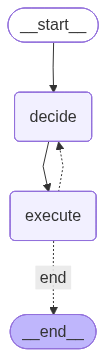

In [2]:
from IPython.display import Image, display
arch = SWEAgent(llm=llm, working_dir=work, max_iterations=8)
graph = arch.build()
try: display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — fix the buggy factorial

The agent should: list files → read factorial.py → identify the missing base case → write fix → run_check to verify → answer.

In [3]:
TASK = (
    f"There is a Python file 'factorial.py' in the working directory that has a bug "
    f"(its tests fail). Read it, identify the bug, write a fix, then run_check it to "
    f"confirm the tests pass. Report what bug you fixed."
)

r = arch.run(TASK)
print(f"ITERATIONS: {r.metadata['iterations']}")
print(f"ACTION_SEQUENCE: {r.metadata['action_sequence']}")
print(f"N_LIST: {r.metadata['n_list_files']}, N_READ: {r.metadata['n_read_file']}, "
      f"N_WRITE: {r.metadata['n_write_file']}, N_RUN: {r.metadata['n_run_check']}")
print()
print('=== OBSERVATIONS ===')
for i, o in enumerate(r.metadata['observations']):
    print(f"[obs {i}] {o[:300]}")
print()
print('=== FINAL ANSWER ===')
print(r.output)
print()
print(f"=== FINAL factorial.py contents ===")
print(buggy_file.read_text())

ITERATIONS: 6
ACTION_SEQUENCE: ['read_file', 'write_file', 'write_file', 'read_file', 'run_check', 'answer']
N_LIST: 0, N_READ: 2, N_WRITE: 2, N_RUN: 1

=== OBSERVATIONS ===
[obs 0] [read_file factorial.py]

def factorial(n):
    # BUG: missing base case for n=0; recursion never terminates
    return n * factorial(n - 1)

if __name__ == "__main__":
    assert factorial(0) == 1, f"factorial(0) should be 1, got {factorial(0)}"
    assert factorial(5) == 120, f"factorial(5) should
[obs 1] [write_file factorial.py] wrote 284 chars
[obs 2] [write_file factorial.py] wrote 256 chars
[obs 3] [read_file factorial.py]
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n - 1)

if __name__ == "__main__":
    assert factorial(0) == 1, f"factorial(0) should be 1, got {factorial(0)}"
    assert factorial(5) == 120, f"factorial(5) should"
[obs 4] [run_check factorial.py] rc=0
stdout: 
stderr: 

=== FINAL ANSWER ===
The bug in the code was a missing base case for t

## 9 · What we just observed

The cells above ran SWE-Agent to fix a buggy `factorial.py` in a sandboxed directory.

### 9.1 · Action sequence

- **Iterations**: 6
- **Sequence**: ['read_file', 'write_file', 'write_file', 'read_file', 'run_check', 'answer']
- **Counts**: list=0, read=2, write=2, run_check=1

### 9.2 · Per-observation log (first 8)

| # | observation excerpt |
|---|---|
| 0 | [read_file factorial.py]

def factorial(n):
    # BUG: missing base case for n=0; recursion never terminates
    return n * factorial(n - 1)

if __name__ == "__main__":
    assert factorial(0) == 1, f |
| 1 | [write_file factorial.py] wrote 284 chars |
| 2 | [write_file factorial.py] wrote 256 chars |
| 3 | [read_file factorial.py]
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n - 1)

if __name__ == "__main__":
    assert factorial(0) == 1, f"factorial(0) should |
| 4 | [run_check factorial.py] rc=0
stdout: 
stderr: 

=== FINAL ANSWER ===
The bug in the code was a missing base case for the factorial function when n=0, causing the recursion to never terminate. The fix |

### 9.3 · Patterns surfaced

- **✅ Full read → write → run cycle** — agent gathered context, fixed, verified.

### 9.4 · The takeaway

SWE-Agent's headline behaviour is the **diagnose → fix → verify** cycle visible in the action sequence: a healthy run shows at least one `read_file` (diagnose), one `write_file` (fix), and one `run_check` (verify). The categorical action enum keeps the agent on a finite, auditable tool surface — and `_safe_path()` ensures it can't escape the sandbox even when it tries.

## 11 · Failure modes & safety

| Failure | Mitigation |
|---|---|
| **Agent escapes sandbox** | Tries `../../etc/passwd` | `_safe_path()` resolves + relative_to check |
| **Agent runs malicious code** | `run_check` executes arbitrary user-written code | Timeout (10s); separate subprocess; in prod: containerise |
| **Agent gives up too early** | Writes a fix that introduces new bug | Force `run_check` after every write; auto-revert on regression |
| **Infinite loop** | Same action repeated | Hard cap on `max_iterations`; force answer on final iter |

Production: replace subprocess with a container (Docker/firejail); restrict tools further (no write_file in shared dirs); audit-log every action.

Reference: Yang et al., *SWE-Agent*. 2024. [arXiv:2405.15793](https://arxiv.org/abs/2405.15793)